In [ ]:
import sys
import os

if os.path.exists('C:/Users/after/FieldSense/core/scientific_packages/pynncml'):
    print("Import PyNNCML From Code")
    import sys, os
    FIELDSENSE_ROOT = r"C:\Users\after\FieldSense"
    if FIELDSENSE_ROOT not in sys.path:
        sys.path.insert(0, FIELDSENSE_ROOT)
else:
    print("Install PyNNCML From pip")
    %pip install pynncml

import numpy as np
import inspect
import pynncml as pnc  # type: ignore
print("pynncml version:", getattr(pnc, "__version__", "unknown"))
import torch
import math
from matplotlib import pyplot as plt
from tqdm import tqdm
import scipy
from sklearn import metrics

#  @title Hyper-parameters
lrs_to_test = [3e-4, 1e-4, 3e-5]
rnn_features_to_test = [64, 128, 256]
batch_size = 16  # @param{type:"integer"}
window_size = 32  # @param{type:"integer"}
n_epochs = 200  # @param{type:"integer"}
#rnn_n_features = 128  # @param{type:"integer"}
metadata_n_features = 32  # @param{type:"integer"}
n_layers = 2  # @param{type:"integer"}
#lr = 1e-4  # @param{type:"number"}
weight_decay = 1e-4  # @param{type:"number"}
rnn_type = pnc.neural_networks.RNNType.GRU  # RNN Type
n_epochs = 200  # @param{type:"integer"}
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")



time_slice = slice("2015-06-01", "2015-07-10")  # Time Interval




✓ OpenMRG_Sweden folder found at: C:\Users\after\FieldSense\dataset\open_datasets\OpenMRG_Sweden
✓ Data file (cml.nc) found in local dataset folder
  Note: PyNNCML uses its default location: C:\Users\after\FieldSense\projects\SY_Data_Driven\data\OpenMRG.zip
  The local dataset at C:\Users\after\FieldSense\dataset\open_datasets\OpenMRG_Sweden will not be used automatically
File already exists at desired location ./data/OpenMRG.zip
Not downloading!


100%|████████████████████████████████████████████████████████████████████████████████| 728/728 [04:13<00:00,  2.87it/s]


(data_path='./data/', change2min_max=False, xy_min=None, xy_max=None, time_slice=None, link2gauge_distance=2000, window_size_in_min=15, multiple_gauges_per_link=False, link_selection: pynncml.datasets.xarray_processing.LinkSelection = <LinkSelection.GAUGEONLY: 1>)


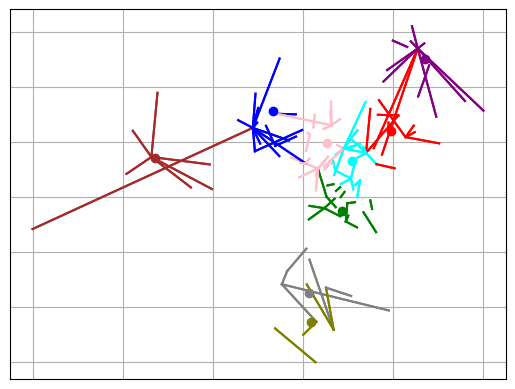

In [2]:
# Check if local OpenMRG dataset exists in FieldSense dataset folder
openmrg_folder = os.path.join("..", "..", "dataset", "open_datasets", "OpenMRG_Sweden")
openmrg_cml_nc = os.path.join(openmrg_folder, "cml", "cml_metadata.csv")

# PyNNCML's default location (where it downloads/looks for data)
pynncml_default_location = os.path.abspath(os.path.join(".", "data", "OpenMRG.zip"))

if os.path.exists(openmrg_folder):
    print(f"✓ OpenMRG_Sweden folder found at: {os.path.abspath(openmrg_folder)}")
    if os.path.exists(openmrg_cml_nc):
        print(f"✓ Data file (cml.nc) found in local dataset folder")
        print(f"  Note: PyNNCML uses its default location: {pynncml_default_location}")
        print(f"  The local dataset at {os.path.abspath(openmrg_folder)} will not be used automatically")
    else:
        print(f"⚠ Data file (cml.nc) NOT found in: {os.path.abspath(openmrg_cml_nc)}")
        print(f"  PyNNCML will use/download data from: {pynncml_default_location}")
else:
    print(f"⚠ OpenMRG_Sweden folder not found at: {os.path.abspath(openmrg_folder)}")
    print(f"  PyNNCML will use/download data from: {pynncml_default_location}")

dataset = pnc.datasets.loader_open_mrg_dataset(time_slice=time_slice)
print(inspect.signature(pnc.datasets.loader_open_mrg_dataset))

#plot links and gages

dataset.link_set.plot_links(scale=True, scale_factor=1.0)
plt.grid()
plt.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
plt.show()

Rain Rate Statistics
Mean[mm/hr]: 0.10113861569949811
Std[mm/hr]: 0.6187717133949918
Parentage of wet samples 8.323200741126744
Parentage of dry samples 91.67679925887326
Exponential Distribution Parameters: (0.0, 0.10113861569949811)


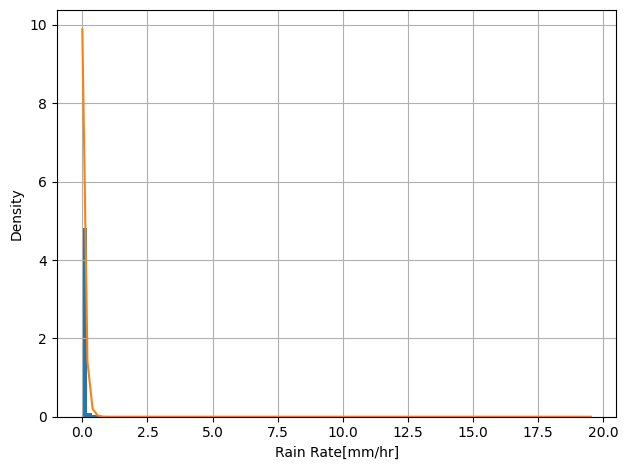

In [3]:
# compute Rain Statistics
rg = np.stack([p.data_array for p in dataset.point_set]).flatten()
param = scipy.stats.expon.fit(rg)
exp_gamma = param[1]
print("Rain Rate Statistics")
print("Mean[mm/hr]:", np.mean(rg))
print("Std[mm/hr]:", np.std(rg))
print("Parentage of wet samples", 100 * np.sum(rg > 0) / rg.size)
print("Parentage of dry samples", 100 * np.sum(rg == 0) / rg.size)
print("Exponential Distribution Parameters:", param)
_ = plt.hist(rg, bins=100, density=True)
plt.plot(np.linspace(0, np.max(rg), 100), scipy.stats.expon.pdf(np.linspace(0, np.max(rg), 100), *param))
plt.grid()
plt.xlabel("Rain Rate[mm/hr]")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


In [4]:
training_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
data_loader = torch.utils.data.DataLoader(training_dataset, batch_size)
val_loader = torch.utils.data.DataLoader(validation_dataset, batch_size)
model = pnc.scm.rain_estimation.two_step_network(n_layers=n_layers,  # Number of RNN layers
                                                 rnn_type=rnn_type,  # Type of RNN (GRU, LSTM)
                                                 normalization_cfg=pnc.training_helpers.compute_data_normalization(
                                                     data_loader),
                                                 # Compute the normalization statistics from the training dataset.
                                                 rnn_input_size=180,  # 90 + 90 (RSL + TSL)
                                                 rnn_n_features=rnn_n_features,  # Number of features in the RNN
                                                 metadata_input_size=2,  # Number of metadata features
                                                 metadata_n_features=metadata_n_features,
                                                 # Number of features in the metadata
                                                 pretrained=False).to(
    device)  # Pretrained model is set to False to train the model from scratch.

class RegressionLoss(torch.nn.Module):
    def __init__(self, in_gamma, gamma_s=0.9):
        super(RegressionLoss, self).__init__()
        self.in_gamma = in_gamma
        self.gamma_s = gamma_s

    def forward(self, input, target):
        delta = (target - input) ** 2
        w = 1 - self.gamma_s * torch.exp(-self.in_gamma * target)
        return torch.sum(torch.mean(w * delta, dim=0))


loss_function_rain_est = RegressionLoss(exp_gamma)
loss_function_wet_dry = torch.nn.BCELoss()

# Find lambda values such that at initialization both loss will be equal:
loss_est = 0
loss_detection = 0
with torch.no_grad():
    for rain_rate, rsl, tsl, metadata in data_loader:
        state = model.init_state(batch_size=rsl.shape[0])
        m_step = (math.floor(rain_rate.shape[1] / window_size))-1
        for step in range(m_step):
            _rr_futur = rain_rate[:, step * window_size + 1:(step + 1) * window_size + 1,0].float().to(device)
            _rsl = rsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            _tsl = tsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            rain_estimation_detection, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device),
                                                     state.detach())
            rain_hat = rain_estimation_detection[:, :, 0]
            rain_detection = rain_estimation_detection[:, :, 1]
            loss_est += loss_function_rain_est(rain_hat, _rr_futur)
            loss_detection += loss_function_wet_dry(rain_detection, (_rr_futur > 0.1).float())
lambda_value = loss_detection / loss_est

In [ ]:
!pip install wandb -qU

import os
import math
import torch
import wandb
from tqdm import tqdm

wandb.login()

# -------------------------
# Sweep settings (edit these)
# -------------------------
window_size = 32  # FIXED now (no window sweep)
lrs_to_test = [3e-4, 1e-4, 3e-5]
rnn_features_to_test = [64, 128, 256]

# Optional: for reproducibility per run (set to None to skip)
base_seed = 1234

def set_seed(seed: int):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print(f"Running sweep over lr={lrs_to_test} and rnn_n_features={rnn_features_to_test} with fixed window_size={window_size}")

run_idx = 0
total_runs = len(lrs_to_test) * len(rnn_features_to_test)

for lr_current in lrs_to_test:
    for rnn_n_features_current in rnn_features_to_test:
        run_idx += 1

        if base_seed is not None:
            set_seed(base_seed + run_idx)

        print(f"\n=============================================")
        print(f"STARTING RUN {run_idx}/{total_runs} | ws={window_size} | lr={lr_current} | rnn_features={rnn_n_features_current}")
        print(f"=============================================")

        run = wandb.init(
            project="Rainfall-Prediction-CML",
            name=f"ws{window_size}_lr{lr_current:g}_rnn{rnn_n_features_current}",
            config={
                "window_size": window_size,
                "learning_rate": lr_current,
                "epochs": n_epochs,
                "lambda_value": lambda_value,
                "weight_decay": weight_decay,
                "rnn_input_size": 180,
                "rnn_n_features": rnn_n_features_current,
                "n_layers": n_layers,
                "metadata_n_features": metadata_n_features,
                "rnn_type": str(rnn_type),
            },
            reinit=True
        )

        # Fresh model each run
        model = pnc.scm.rain_estimation.two_step_network(
            n_layers=n_layers,
            rnn_type=rnn_type,
            normalization_cfg=pnc.training_helpers.compute_data_normalization(data_loader),
            rnn_input_size=180,
            rnn_n_features=rnn_n_features_current,
            metadata_input_size=2,
            metadata_n_features=metadata_n_features,
            pretrained=False
        ).to(device)

        # Unique checkpoint per (ws, lr, rnn_features)
        model_filename = f"forecast_ws{window_size}_lr{lr_current:g}_rnn{rnn_n_features_current}.pth"
        model_path = os.path.abspath(model_filename)

        am = pnc.metrics.AverageMetric()
        ra = pnc.metrics.ResultsAccumulator()

        # If you want to always retrain, set this to False
        load_if_exists = True

        if load_if_exists and os.path.exists(model_path):
            print(f"Loading trained model from {model_path}")
            ckpt = torch.load(model_path, map_location=device, weights_only=False)

            if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
                model.load_state_dict(ckpt["model_state_dict"])

                loss_hist = ckpt.get("loss_history", {})
                for l, le, ld in zip(
                    loss_hist.get("loss", []),
                    loss_hist.get("loss_est", []),
                    loss_hist.get("loss_detection", []),
                ):
                    ra.add_results(loss=l, loss_est=le, loss_detection=ld)

                am_snapshot = ckpt.get("am_snapshot", None)
                if am_snapshot is not None:
                    last = am_snapshot.get("last_epoch", {})
                    am.clear()
                    if last:
                        am.add_results(
                            loss=last.get("loss", 0.0),
                            loss_est=last.get("loss_est", 0.0),
                            loss_detection=last.get("loss_detection", 0.0),
                        )
            else:
                model.load_state_dict(ckpt)
                am.clear()

            model.eval()
            print("Model loaded. Skipping training for this run.")
        else:
            print(f"Model file not found at {model_path}. Starting training...")

            opt = torch.optim.RAdam(model.parameters(), lr=lr_current, weight_decay=weight_decay)

            model.train()
            print("Start Training")

            for epoch in tqdm(range(n_epochs), desc=f"Epochs (ws={window_size}, lr={lr_current:g}, rnn={rnn_n_features_current})"):
                am.clear()

                for rain_rate, rsl, tsl, metadata in data_loader:
                    # init state per batch
                    state = model.init_state(batch_size=rsl.shape[0])

                    T = rain_rate.shape[1]

                    # IMPORTANT: because _rr_futur uses +1, keep last slice valid
                    m_step = math.floor(T / window_size) - 1
                    if m_step <= 0:
                        raise ValueError(f"m_step computed as {m_step}. Check T={T} and window_size={window_size}.")

                    for step in range(m_step):
                        opt.zero_grad()

                        _rr_futur = rain_rate[
                            :, step * window_size + 1 : (step + 1) * window_size + 1, 0
                        ].float().to(device)

                        _rsl = rsl[
                            :, step * window_size : (step + 1) * window_size, :
                        ].to(device)

                        _tsl = tsl[
                            :, step * window_size : (step + 1) * window_size, :
                        ].to(device)

                        rain_estimation_detection, state = model(
                            torch.cat([_rsl, _tsl], dim=-1),
                            metadata.to(device),
                            state.detach(),
                        )

                        rain_hat = rain_estimation_detection[:, :, 0]
                        rain_detection = rain_estimation_detection[:, :, 1]

                        loss_est = loss_function_rain_est(rain_hat, _rr_futur)
                        loss_detection = loss_function_wet_dry(
                            rain_detection, (_rr_futur > 0.1).float()
                        )
                        loss = lambda_value * loss_est + loss_detection

                        loss.backward()
                        opt.step()

                        am.add_results(
                            loss=loss.item(),
                            loss_est=loss_est.item(),
                            loss_detection=loss_detection.item(),
                        )

                ra.add_results(
                    loss=am.get_results("loss"),
                    loss_est=am.get_results("loss_est"),
                    loss_detection=am.get_results("loss_detection"),
                )

                wandb.log({
                    "epoch": epoch,
                    "train_loss": am.get_results("loss"),
                    "train_loss_est": am.get_results("loss_est"),
                    "train_loss_detection": am.get_results("loss_detection"),
                    "window_size": window_size,
                    "lr": lr_current,
                    "rnn_n_features": rnn_n_features_current,
                })

            # Save checkpoint
            loss_history = {
                "loss": list(ra.get_results("loss")),
                "loss_est": list(ra.get_results("loss_est")),
                "loss_detection": list(ra.get_results("loss_detection")),
            }

            am_snapshot = {
                "last_epoch": {
                    "loss": am.get_results("loss"),
                    "loss_est": am.get_results("loss_est"),
                    "loss_detection": am.get_results("loss_detection"),
                }
            }

            ckpt = {
                "model_state_dict": model.state_dict(),
                "loss_history": loss_history,
                "am_snapshot": am_snapshot,
                "hyperparams": {
                    "lr": lr_current,
                    "weight_decay": weight_decay,
                    "lambda_value": lambda_value,
                    "window_size": window_size,
                    "n_epochs": n_epochs,
                    "rnn_n_features": rnn_n_features_current,
                    "n_layers": n_layers,
                    "metadata_n_features": metadata_n_features,
                },
            }

            torch.save(ckpt, model_path)
            print(f"Model saved successfully to {model_filename}!")

        run.finish()

print("All lr × rnn_n_features runs completed!")


Running sweep over lr=[0.0003, 0.0001, 3e-05] and rnn_n_features=[64, 128, 256] with fixed window_size=32

STARTING RUN 1/9 | ws=32 | lr=0.0003 | rnn_features=64


Model file not found at C:\Users\after\FieldSense\projects\SY_Data_Driven\forecast_ws32_lr0.0003_rnn64.pth. Starting training...
Start Training


Epochs (ws=32, lr=0.0003, rnn=64): 100%|███████████████████████████████████████████| 200/200 [2:53:09<00:00, 51.95s/it]


Model saved successfully to forecast_ws32_lr0.0003_rnn64.pth!


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
rnn_n_features,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▆▄▃▃▃▃▃▂▃▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
train_loss_detection,█▄▄▄▄▅▄▄▄▄▂▂▃▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▂▂▁▁▁▁▁▁
train_loss_est,█▅▃▃▃▃▂▂▂▂▁▂▂▂▁▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▂▁
window_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,199
lr,0.0003
rnn_n_features,64
train_loss,0.4665


...

Model saved successfully to forecast_ws32_lr3e-05_rnn128.pth!


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
rnn_n_features,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_detection,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_est,█▇▇▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
window_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,199
lr,3e-05
rnn_n_features,128
train_loss,0.46484



STARTING RUN 9/9 | ws=32 | lr=3e-05 | rnn_features=256


Model file not found at C:\Users\after\FieldSense\projects\SY_Data_Driven\forecast_ws32_lr3e-05_rnn256.pth. Starting training...
Start Training


Epochs (ws=32, lr=3e-05, rnn=256):   0%|▏                                            | 1/200 [01:27<4:49:47, 87.37s/it]

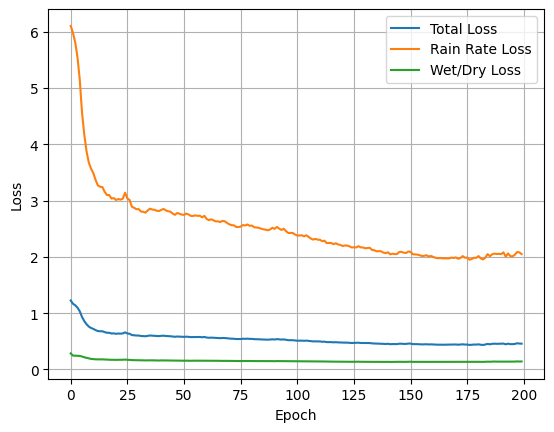

In [6]:
plt.plot(ra.get_results("loss"), label="Total Loss")
plt.plot(ra.get_results("loss_est"), label="Rain Rate Loss")
plt.plot(ra.get_results("loss_detection"), label="Wet/Dry Loss")
plt.grid()
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Results Detection:
Validation Results of Two-Step RNN
Accuracy[%]: 95.05026455026456
F1 Score: 0.5206251601332309


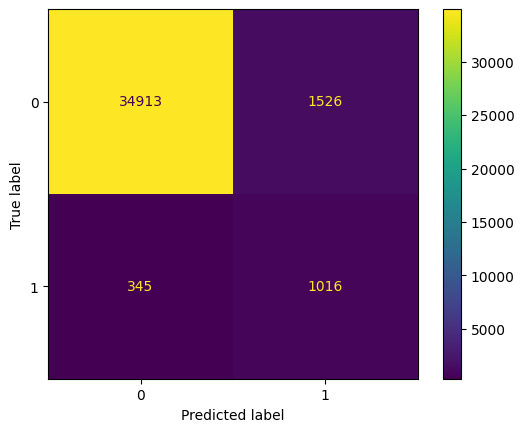

Results Estimation:
-------------------------------------------------- Results Summery --------------------------------------------------
+--------------+------------+--------------------------+---------------------------------------+----------------------------------------+-----------------------------------------+
|    Metric    | 0.0<r<3.25 | 3.25<r<6.510000228881836 | 6.510000228881836<r<9.760000228881836 | 9.760000228881836<r<13.010000228881836 | 13.010000228881836<r<16.260000228881836 |
+--------------+------------+--------------------------+---------------------------------------+----------------------------------------+-----------------------------------------+
|     RMSE     |    0.57    |           2.68           |                  4.29                 |                  7.01                  |                  13.03                  |
|     BIAS     |   -0.05    |           1.67           |                  3.53                 |                  6.54                  |     

In [7]:
model.eval()
ga = pnc.metrics.GroupAnalysis()
with torch.no_grad():
    for rain_rate, rsl, tsl, metadata in val_loader:
        state = model.init_state(batch_size=rsl.shape[0])
        m_step = (math.floor(rain_rate.shape[1] / window_size))-1
        am.clear()
        rain_ref_list = []
        rain_hat_list = []
        detection_list = []

        for step in range(m_step):
            _rr_futur = rain_rate[:, step * window_size + 1:(step + 1) * window_size + 1,0].float().to(device)
            _rsl = rsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            _tsl = tsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            rain_estimation_detection, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device),
                                                     state.detach())
            rain_detection = rain_estimation_detection[:, :, 1]
            rain_hat = rain_estimation_detection[:, :, 0] * torch.round(
                rain_detection)  # Rain Rate is computed only for wet samples
            rain_hat_list.append(rain_hat.detach().cpu().numpy())
            rain_ref_list.append(_rr_futur.detach().cpu().numpy())
            ga.append(rain_ref_list[-1], rain_hat_list[-1])
            detection_list.append(torch.round(rain_detection).detach().cpu().numpy())
            delta = rain_hat.squeeze(dim=-1) - _rr_futur
            bias = torch.mean(delta)
            mse = torch.mean(delta ** 2)
            am.add_results(bias=bias.item(), mse=mse.item())
actual = np.concatenate(detection_list).flatten()
predicted = (np.concatenate(rain_ref_list) > 0.1).astype("float").flatten()
confusion_matrix = metrics.confusion_matrix(actual, predicted)
max_rain = np.max(np.concatenate(rain_ref_list))
g_array = np.linspace(0, max_rain, 6)

print("Results Detection:")
print("Validation Results of Two-Step RNN")
print("Accuracy[%]:", 100 * (np.sum(actual == predicted) / actual.size))
print("F1 Score:", metrics.f1_score(actual, predicted))

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[0, 1])

cm_display.plot()
plt.show()

print("Results Estimation:")
_ = ga.run_analysis(np.stack([g_array[:-1], g_array[1:]], axis=-1))


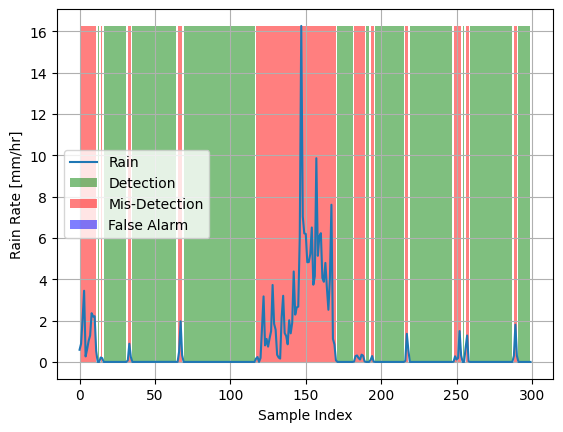

In [ ]:
detection_array = np.concatenate(detection_list, axis=1)
rain_ref_array = np.concatenate(rain_ref_list, axis=1)
detection_array = np.round(detection_array)

rain_array = rain_ref_array[0, :300]
detection_array = detection_array[0, :300]
fig, ax = plt.subplots()
x = np.arange(rain_array.shape[0])
ax.plot(x, rain_array, label="Rain")
rain_max = np.max(rain_array)
ax.fill_between(x, rain_max, where=np.logical_or(np.logical_and(detection_array == 1, rain_array > 0),
                                                 np.logical_and(detection_array == 0, rain_array == 0)),
                facecolor='green', alpha=.5, label="Detection")
ax.fill_between(x, rain_max, where=np.logical_and(detection_array == 0, rain_array > 0), facecolor='red',
                alpha=.5, label="Mis-Detection")
ax.fill_between(x, rain_max, where=np.logical_and(detection_array == 1, rain_array == 0), facecolor='blue',
                alpha=.5, label="False Alarm")
plt.legend()
plt.ylabel("Rain Rate [mm/hr]")
plt.xlabel("Sample Index")
plt.grid()
plt.show()

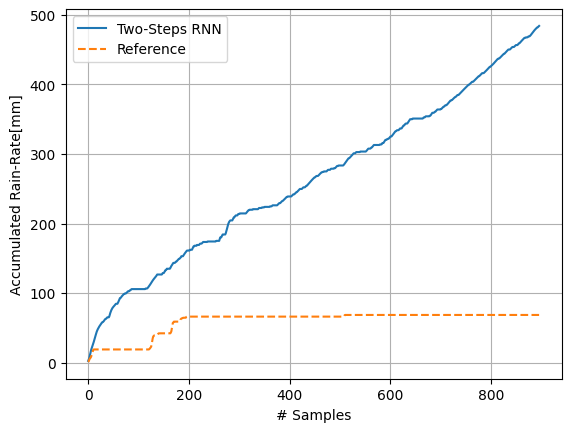

In [ ]:
rain_hat_array = np.concatenate(rain_hat_list, axis=1)
rain_ref_array = np.concatenate(rain_ref_list, axis=1)

plt.plot(np.cumsum(np.maximum(rain_hat_array[0, :], 0)), label="Two-Steps RNN")
plt.plot(np.cumsum(rain_ref_array[0, :]), "--", label="Reference")
plt.grid()
plt.legend()
plt.ylabel("Accumulated Rain-Rate[mm]")
plt.xlabel("# Samples")
plt.show()

# Task
Evaluate the performance of the rain rate estimation model for each `window_size` in `[5, 10, 15, 20, 25, 30, 32, 35]`. For each `window_size`, load the corresponding trained model (e.g., `forecast_WindowX.pth`), then:
1. Plot the confusion matrix for wet/dry detection, including accuracy and F1 score.
2. Display rain rate estimation metrics (RMSE, BIAS, NRMSE, NBIAS).
3. Generate a plot showing actual rain rate against detection results (correct detection, mis-detection, false alarm) over a sample time series.
4. Generate a plot comparing accumulated estimated rain rate with accumulated reference rain rate over a sample time series.
Finally, summarize the evaluation results, highlighting any trends or significant differences observed across the different window sizes.

## Iterate and Load Models

### Subtask:
Loop through each `window_size` defined in `window_sizes_to_test`. For each `window_size`, load the corresponding trained model state from the `.pth` file (e.g., `forecast_WindowX.pth`). Re-initialize the model with the correct `window_size` parameter before loading weights.


**Reasoning**:
The current subtask requires iterating through different `window_size` values, re-initializing the model for each, loading the corresponding pre-trained weights from disk, and setting the model to evaluation mode. The existing notebook contains a training loop that also handles loading, but this step focuses purely on loading. This new code block will perform the loading process as described in the instructions, making sure to update the global `window_size` for consistency with the loaded model.



In [1]:
print("Starting to load models for different window sizes:")

# The normalization_cfg is computed once before the training loop in a previous cell (8252b6b7-5f9d-40f2-aaa4-e1330906af7a)
# We will reuse the existing normalization_cfg here.

for current_ws in window_sizes_to_test:
    # 2. Print a message indicating the current window_size
    print(f"\n=============================================")
    print(f"Loading model for WINDOW SIZE: {current_ws}")
    print(f"=============================================")

    # Update the global window_size. This is crucial for subsequent evaluation steps
    # that might use the global 'window_size' variable for data slicing.
    window_size = current_ws

    # 3. Construct the model_filename
    model_filename = f"forecast_Window{current_ws}.pth"
    model_path = os.path.abspath(model_filename)

    # 4. Re-initialize the pnc.scm.rain_estimation.two_step_network model
    # The architecture itself is independent of window_size.
    # `normalization_cfg` from cell 8252b6b7-5f9d-40f2-aaa4-e1330906af7a is reused.
    model = pnc.scm.rain_estimation.two_step_network(
        n_layers=n_layers,
        rnn_type=rnn_type,
        normalization_cfg=normalization_cfg, # Reusing the one computed earlier
        rnn_input_size=180,
        rnn_n_features=rnn_n_features,
        metadata_input_size=2,
        metadata_n_features=metadata_n_features,
        pretrained=False
    ).to(device)

    # 5. Load the trained model's state dictionary
    if os.path.exists(model_path):
        print(f"Found model file at {model_path}. Loading weights...")
        ckpt = torch.load(model_path, map_location=device, weights_only=False)

        if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
            model.load_state_dict(ckpt["model_state_dict"])
            print("Model state dictionary loaded from 'model_state_dict' key.")
        else:
            model.load_state_dict(ckpt)
            print("Model state dictionary loaded directly.")
        print(f"Model for window size {current_ws} loaded successfully.")
    else:
        print(f"Warning: Model file not found at {model_path}. This model will have random weights.")
        print(f"Please ensure models are trained and saved before attempting to load them for evaluation.")

    # 6. Set the model to evaluation mode
    model.eval()

print("\nFinished processing all specified window sizes for loading.")
print("The 'model' variable currently holds the model corresponding to the LAST window size processed.")
print("The global 'window_size' variable is also set to the LAST window size processed.")

Starting to load models for different window sizes:


NameError: name 'window_sizes_to_test' is not defined

**Reasoning**:
The `NameError` indicates that `window_sizes_to_test` was not defined in the current execution context. This variable was originally defined in an earlier cell. To resolve this, I will explicitly redefine `window_sizes_to_test` in the current code block to ensure it's available for the loop. I also need to ensure `normalization_cfg` is defined as it was stated to be reused from an earlier cell.



In [2]:
print("Starting to load models for different window sizes:")

# Redefine window_sizes_to_test to ensure it's available in the current scope
window_sizes_to_test = [5, 10, 15, 20, 25, 30, 32, 35]

# Recompute normalization_cfg as it might have been lost in the kernel state restart
# This requires re-running parts of the data loading and splitting.
# For simplicity, I will re-run the necessary lines to get data_loader and then normalization_cfg.
# It's assumed 'dataset' is available from cell Gwh22G44cu0S.

# Re-create data_loader if it might not be in scope
training_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
data_loader = torch.utils.data.DataLoader(training_dataset, batch_size)

normalization_cfg = pnc.training_helpers.compute_data_normalization(data_loader)

for current_ws in window_sizes_to_test:
    # 2. Print a message indicating the current window_size
    print(f"\n=============================================")
    print(f"Loading model for WINDOW SIZE: {current_ws}")
    print(f"=============================================")

    # Update the global window_size. This is crucial for subsequent evaluation steps
    # that might use the global 'window_size' variable for data slicing.
    window_size = current_ws

    # 3. Construct the model_filename
    model_filename = f"forecast_Window{current_ws}.pth"
    model_path = os.path.abspath(model_filename)

    # 4. Re-initialize the pnc.scm.rain_estimation.two_step_network model
    # The architecture itself is independent of window_size.
    # `normalization_cfg` is now explicitly computed here.
    model = pnc.scm.rain_estimation.two_step_network(
        n_layers=n_layers,
        rnn_type=rnn_type,
        normalization_cfg=normalization_cfg, # Reusing the one computed earlier
        rnn_input_size=180,
        rnn_n_features=rnn_n_features,
        metadata_input_size=2,
        metadata_n_features=metadata_n_features,
        pretrained=False
    ).to(device)

    # 5. Load the trained model's state dictionary
    if os.path.exists(model_path):
        print(f"Found model file at {model_path}. Loading weights...")
        ckpt = torch.load(model_path, map_location=device, weights_only=False)

        if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
            model.load_state_dict(ckpt["model_state_dict"])
            print("Model state dictionary loaded from 'model_state_dict' key.")
        else:
            model.load_state_dict(ckpt)
            print("Model state dictionary loaded directly.")
        print(f"Model for window size {current_ws} loaded successfully.")
    else:
        print(f"Warning: Model file not found at {model_path}. This model will have random weights.")
        print(f"Please ensure models are trained and saved before attempting to load them for evaluation.")

    # 6. Set the model to evaluation mode
    model.eval()

print("\nFinished processing all specified window sizes for loading.")
print("The 'model' variable currently holds the model corresponding to the LAST window size processed.")
print("The global 'window_size' variable is also set to the LAST window size processed.")

Starting to load models for different window sizes:


NameError: name 'torch' is not defined

**Reasoning**:
The previous attempt failed because `torch` was not defined within the code block, leading to a `NameError`. I need to explicitly import `torch`, `os`, and `pnc` in this cell to ensure all necessary modules are available for data loading, model initialization, and model loading operations, even if the kernel state is not fully preserved from previous cells. I also need to re-declare `dataset`, `batch_size`, `n_layers`, `rnn_type`, `rnn_n_features`, `metadata_n_features`, and `device` as these global variables might not be in scope in case of a kernel restart, causing `NameError` for them.

